# AC209B: Milestone 4
## Group 8: Generative Models for Knowledge Graph Construction

**Harvard John A. Paulson School of Engineering and Applied Sciences, Spring 2026**

| | |
|---|---|
| **Group** | 44 |
| **Members** | Karlo Vrancic, Emma Harris, Anastasia Ahani, Robert Debbas, Lila Schoen |
| **Milestone** | MS4: Final Pipeline & GraphRAG Evaluation |

---

## Overview

This notebook implements and evaluates the full end-to-end pipeline for our project. We compare two approaches to knowledge graph (KG) construction for downstream multi-hop question answering:

- **g1** : KG extracted by a LoRA fine-tuned Llama-3.2-3B (trained on WebNLG). Graphs pre-built and saved to `./data/hotpot_graphs_g1.json`.
- **g2** : KG produced by the pipeline: `Base LLM → GVAE denoiser → Base LLM reconcile`. Built and run in this notebook.

Both graphs are then evaluated using **GraphRAG** on HotpotQA multi-hop questions, with GPT-4.1 as the big LLM reader.

---

## Table of Contents
1. [Dependencies & Environment](#1-dependencies--environment)
2. [Shared Utilities](#2-shared-utilities)
3. [Load GVAE : Graph Quality Scorer](#3-load-gvae--graph-quality-scorer)
4. [g2 Pipeline: Base LLM → GVAE → Base LLM](#4-g2-pipeline-base-llm--gvae--base-llm)
5. [Load HotpotQA & Pre-built g1 Graphs](#5-load-hotpotqa--pre-built-g1-graphs)
6. [Build g2 Graphs for HotpotQA](#6-build-g2-graphs-for-hotpotqa)
7. [GraphRAG Retrieval & Evaluation](#7-graphrag-retrieval--evaluation)
8. [Results: g1 vs g2 Comparison](#8-results-g1-vs-g2-comparison)

---

## Data & Checkpoint Paths

The following files must be present before running this notebook:

| File | Description |
|---|---|
| `./checkpoints/gvae_model_v2.pt` | Trained GVAE weights |
| `./checkpoints/gvae_config.json` | GVAE hyperparameters |
| `./data/hotpot_graphs_g1.json` | Pre-built g1 graphs (50 HotpotQA examples) |

Internet access is required to download DBpedia (for GVAE training data) and HotpotQA.

## 1a. Dependencies & Environment

In [2]:
%pip install -q \
    "transformers==4.45.0" \
    "peft==0.13.2" \
    "accelerate==0.34.0" \
    "bitsandbytes>=0.43.0" \
    "datasets==2.20.0" \
    "openai>=1.0.0" \
    "networkx" \
    "matplotlib" \
    "pandas" \
    "tqdm"

print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 52.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.
Dependencies 

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
print("Using GPU 2")

import gzip, json, re, string, random, urllib.request, bz2, time
from collections import Counter, defaultdict, deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm
from datasets import load_dataset
from openai import OpenAI

from google.colab import drive
drive.mount("/content/drive")
# os.chdir('/content/drive/MyDrive/Project-KG')

# ── API keys ────────────────────────────────────────────────────────
OPENAI_API_KEY = ""
HF_TOKEN       = ""
BIG_LLM_MODEL  = "gpt-5.5"

# ── Paths ───────────────────────────────────────────────────────────
CHECKPOINT_DIR  = Path("./checkpoints"); CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR     = Path("./graphrag_eval"); RESULTS_DIR.mkdir(exist_ok=True)

GVAE_MODEL_PATH  = CHECKPOINT_DIR / "gvae_model.pt"
GVAE_CONFIG_PATH = CHECKPOINT_DIR / "gvae_config.json"
G1_GRAPHS_PATH   = Path("./graphrag_eval/hotpot_graphs_g1.json")
G2_GRAPHS_PATH   = Path("./graphrag_eval/hotpot_graphs_g2.json")
G0_GRAPHS_PATH   = Path("./graphrag_eval/hotpot_graphs_g0.json")
G1_RESULTS_PATH  = Path("./graphrag_eval/graphrag_results.json")
G2_RESULTS_PATH  = Path("./graphrag_eval/graphrag_g2_results.json")
G0_RESULTS_PATH  = Path("./graphrag_eval/graphrag_g0_results.json")

N_EXAMPLES    = 20
BFS_HOPS      = 2
MIN_TOK_LEN   = 3
MAX_PASS_CHARS = 500

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using GPU 2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


## 1b. Full Project Pipeline

This notebook is the final evaluation stage. We compare **three** graph construction strategies:

| Graph | Extractor | Description |
|---|---|---|
| **g0** | Base Llama-3.2-3B (no fine-tuning) | Raw instruction-prompted extraction |
| **g1** | Fine-tuned Llama-3.2-3B (WebNLG LoRA) | SFT-trained extractor |
| **g2** | Base Llama → GVAE → Base Llama | VAE-enhanced base pipeline |

**Step 1: WebNLG LoRA Fine-tuning** (`KG_SFT_Final.ipynb`)
Llama-3.2-3B fine-tuned on 10,000 WebNLG examples, 2 epochs, QLoRA. Adapter at `./webnlg_lora/lora_adapter/`.

**Step 2: DBpedia Subgraph Sampling** (`pipeline.ipynb`)
20,000 subgraphs sampled from DBpedia using BFS. Saved to `./subgraphs/`.

**Step 3: GVAE Training** (`pipeline.ipynb`)
Graph VAE trained on 20,000 DBpedia subgraphs with contrastive loss. Checkpoint at `./checkpoints/gvae_model.pt`.

**Step 4: Graph Construction** (`build_graphs_g1.py` + this notebook)
- g1 pre-built by fine-tuned extractor → `./graphrag_eval/hotpot_graphs_g1.json`
- g0 and g2 built in this notebook (Sections 6a and 6b) from the same 20 examples

**Step 5: GraphRAG Evaluation** (this notebook, Section 7)
All three graphs evaluated with GraphRAG + GPT-4.1 on the same 20 HotpotQA questions.


## 2. Shared Utilities

To pass a knowledge graph through the GVAE, we need to convert it into a fixed size
numerical tensor and back. Three functions handle this:

- **`order_by_degree`**: assigns a canonical index to each node and relation so that
  the same graph always maps to the same tensor, regardless of the order triples were extracted.
  Nodes are ranked by how many connections they have (most connected = index 0).

- **`graph_to_tensor`**: converts a list of (subject, relation, object) triples into a
  3D binary array of shape `(max_nodes, max_nodes, max_relations)`. Entry `[i, j, k] = 1`
  means "there is an edge of relation type k from node i to node j."

- **`tensor_to_graph`**: the inverse: converts the GVAE's output probability tensor back
  into triples by keeping only edges where the reconstruction probability exceeds a threshold.

These three functions are the bridge between the symbolic world (triples) and the
numerical world (tensors) that the GVAE operates in.

In [ ]:
def order_by_degree(triples):
    """
    Return (nodes, relations, indexed_triples) with a canonical ordering.
    Nodes sorted by (-degree, label): highest-degree first, alphabetic on ties.
    Relations sorted alphabetically.
    This ensures the same graph always maps to the same adjacency tensor.
    """
    deg = Counter()
    for s, _, o in triples:
        deg[s] += 1
        deg[o] += 1

    nodes     = sorted(deg, key=lambda n: (-deg[n], n))
    relations = sorted({r for _, r, _ in triples})

    n_idx = {n: i for i, n in enumerate(nodes)}
    r_idx = {r: i for i, r in enumerate(relations)}
    indexed = [(n_idx[s], r_idx[r], n_idx[o]) for s, r, o in triples]

    return nodes, relations, indexed


def graph_to_tensor(triples, max_nodes, max_relations):
    """
    Convert a list of (subject, relation, object) tuples into a
    (max_nodes, max_nodes, max_relations) binary adjacency tensor.
    Returns (tensor, nodes, relations) or None if graph exceeds limits.
    """
    nodes, relations, indexed = order_by_degree(triples)
    if len(nodes) > max_nodes or len(relations) > max_relations:
        return None
    A = np.zeros((max_nodes, max_nodes, max_relations), dtype=np.float32)
    for s_idx, r_idx, o_idx in indexed:
        A[s_idx, o_idx, r_idx] = 1.0
    return A, nodes, relations


def tensor_to_graph(A, nodes, relations, threshold=0.5):
    """
    Convert a (N, N, R) probability tensor back to a list of
    (subject, relation, object) tuples where probability >= threshold.
    """
    triples = []
    for i, s in enumerate(nodes):
        for j, o in enumerate(nodes):
            for k, r in enumerate(relations):
                if A[i, j, k] >= threshold:
                    triples.append((s, r, o))
    return triples


print("Shared graph utilities defined.")

Shared graph utilities defined.


## 3. Load GVAE: Graph Quality Scorer

The GVAE (Graph Variational Autoencoder) was trained on 20,000 DBpedia subgraphs.
It learns the structural distribution of clean knowledge graphs. When an extracted graph is passed
through the GVAE, the reconstruction probabilities indicate how "normal" each edge is. Edges
with low reconstruction probability are flagged as likely hallucinations or structural anomalies.

The GVAE uses:
- **Encoder:** 2-layer MLP --> mean and log-variance of latent Gaussian
- **Decoder:** 2-layer MLP --> reconstructed adjacency tensor logits
- **Training loss:** BCE reconstruction + $\beta$·KL divergence + contrastive margin loss

The contrastive training explicitly pushes the model to assign lower BCE to clean graphs
than to graphs with randomly corrupted relations, improving its ability to flag noisy triples.

> **Note:** The training code is in `pipeline.ipynb`. This cell only
> loads the pre-trained checkpoint from `./checkpoints/gvae_model.pt`.

In [ ]:
class GVAE(nn.Module):
    """Graph Variational Autoencoder over flattened adjacency tensors."""

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder   = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# ── Load checkpoint ─────────────────────────────────────────────────
assert GVAE_CONFIG_PATH.exists(), f"GVAE config not found at {GVAE_CONFIG_PATH}"
assert GVAE_MODEL_PATH.exists(),  f"GVAE weights not found at {GVAE_MODEL_PATH}"

with open(GVAE_CONFIG_PATH) as f:
    gvae_config = json.load(f)

MAX_NODES     = gvae_config["max_nodes"]
MAX_RELATIONS = gvae_config["max_relations"]
GVAE_THRESHOLD = gvae_config.get("threshold", 0.5)
INPUT_DIM      = MAX_NODES * MAX_NODES * MAX_RELATIONS
HIDDEN_DIM     = gvae_config.get("hidden_dim", 256)
LATENT_DIM     = gvae_config.get("latent_dim", 32)

gvae = GVAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
gvae.load_state_dict(torch.load(str(GVAE_MODEL_PATH), map_location=DEVICE))
gvae.eval()

print(f"GVAE loaded. Config:")
print(f"  max_nodes={MAX_NODES}, max_relations={MAX_RELATIONS}")
print(f"  threshold={GVAE_THRESHOLD}, hidden_dim={HIDDEN_DIM}, latent_dim={LATENT_DIM}")

GVAE loaded. Config:
  max_nodes=10, max_relations=7
  threshold=0.8, hidden_dim=256, latent_dim=32


In [ ]:
def score_triples_masked(triples, gvae_model, max_nodes=MAX_NODES, max_relations=MAX_RELATIONS):
    """
    Score each triple by masking it out and checking the GVAE's reconstruction
    probability at that position.

    Higher score (closer to 0) = more plausible triple.
    Lower score (more negative) = suspicious triple.

    Returns (per_triple_log_probs, kept_triples).
    """
    if not triples:
        return None, []

    # Fit graph into tensor; truncate if too large
    result = graph_to_tensor(triples, max_nodes, max_relations)
    if result is None:
        nodes_all, rels_all, _ = order_by_degree(triples)
        nodes     = nodes_all[:max_nodes]
        relations = rels_all[:max_relations]
        n_idx = {n: i for i, n in enumerate(nodes)}
        r_idx = {r: i for i, r in enumerate(relations)}
        kept = [(s, r, o) for (s, r, o) in triples
                if s in n_idx and o in n_idx and r in r_idx]
        if not kept:
            return None, []
        result = graph_to_tensor(kept, max_nodes, max_relations)
        if result is None:
            return None, kept
    else:
        kept = list(triples)

    A, nodes, relations = result
    n_idx = {n: i for i, n in enumerate(nodes)}
    r_idx = {r: i for i, r in enumerate(relations)}

    per_triple_scores = []
    for (s, r, o) in kept:
        i, j, k = n_idx[s], n_idx[o], r_idx[r]
        A_masked = A.copy()
        A_masked[i, j, k] = 0.0
        x = torch.from_numpy(A_masked).to(DEVICE).view(1, -1)
        with torch.no_grad():
            recon_logits, _, _ = gvae_model(x)
            logit = recon_logits.view(max_nodes, max_nodes, max_relations)[i, j, k].item()
        log_prob = min(logit, 0) - np.log1p(np.exp(-abs(logit)))
        per_triple_scores.append(log_prob)

    return per_triple_scores, kept


def gvae_denoise(extracted_triples, gvae_model, threshold=GVAE_THRESHOLD,
                 max_nodes=MAX_NODES, max_relations=MAX_RELATIONS):
    """
    Pass extracted triples through the GVAE encoder-decoder.
    Returns (denoised_triples, original_kept_triples) where denoised_triples
    are decoded from the GVAE's reconstruction at the given threshold.
    """
    if not extracted_triples:
        return [], []

    triple_tuples = [(t["subject"], t["relation"], t["object"])
                     for t in extracted_triples]

    result = graph_to_tensor(triple_tuples, max_nodes, max_relations)
    if result is None:
        nodes_all, rels_all, _ = order_by_degree(triple_tuples)
        nodes     = nodes_all[:max_nodes]
        relations = rels_all[:max_relations]
        n_idx = {n: i for i, n in enumerate(nodes)}
        r_idx = {r: i for i, r in enumerate(relations)}
        kept = [(s, r, o) for (s, r, o) in triple_tuples
                if s in n_idx and o in n_idx and r in r_idx]
        if not kept:
            return [], []
        result = graph_to_tensor(kept, max_nodes, max_relations)
        if result is None:
            return [], kept
    else:
        kept = list(triple_tuples)

    A, nodes, relations = result
    x = torch.from_numpy(A).to(DEVICE).view(1, -1)
    with torch.no_grad():
        recon_logits, _, _ = gvae_model(x)
        recon_probs = torch.sigmoid(recon_logits).view(
            max_nodes, max_nodes, max_relations
        ).cpu().numpy()

    denoised_tuples = tensor_to_graph(recon_probs, nodes, relations, threshold=threshold)
    denoised = [{"subject": s, "relation": r, "object": o} for (s, r, o) in denoised_tuples]
    kept_dicts = [{"subject": s, "relation": r, "object": o} for (s, r, o) in kept]
    return denoised, kept_dicts


print("GVAE scoring and denoising functions defined.")

GVAE scoring and denoising functions defined.


### GVAE Training Code (reference only, no running here)

The GVAE was trained by Anastasia in `pipeline.ipynb`. The key training loop
used contrastive learning: clean graphs are pushed to have lower reconstruction
error than graphs with randomly corrupted relations.

In [ ]:
# ── GVAE Training (NOT RUN HERE — see pipeline.ipynb) ──────────────
# Included for reproducibility. Run pipeline.ipynb to retrain from scratch.

# EPOCHS        = 30
# BATCH_SIZE    = 64
# LATENT_DIM    = 32
# HIDDEN_DIM    = 256
# LR            = 1e-3
# BETA_MAX      = 0.1          # KL weight
# LAMBDA_CONTRAST = 0.5        # contrastive margin loss weight
# MARGIN        = 2.0          # clean BCE must be this much lower than corrupt BCE
# CORRUPT_FRAC  = 0.5          # fraction of edges randomly corrupted

# model = GVAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
# optim = torch.optim.Adam(model.parameters(), lr=LR)

# for epoch in range(1, EPOCHS + 1):
#     beta_now = BETA_MAX * min(1.0, epoch / 10)
#     model.train()
#     for (x,) in train_loader:
#         x = x.to(DEVICE).view(x.size(0), -1)
#         loss, _, _, _, _ = contrastive_step(model, x, pos_weight, beta_now,
#                                              LAMBDA_CONTRAST, MARGIN, CORRUPT_FRAC)
#         optim.zero_grad(); loss.backward(); optim.step()
#     # ... validation loop ...
#     # Save best checkpoint
#     torch.save(best_state, "checkpoints/gvae_model.pt")
#     json.dump({"max_nodes": MAX_NODES, "max_relations": MAX_RELATIONS,
#                "threshold": 0.5, "hidden_dim": HIDDEN_DIM,
#                "latent_dim": LATENT_DIM}, open("checkpoints/gvae_config.json", "w"))

## 4. g2 Pipeline: Base LLM --> GVAE --> Base LLM

The g2 graph construction pipeline works as follows:

1. **Base LLM extraction**: Llama-3.2-3B-Instruct (no fine-tuning) extracts raw triples from text
2. **GVAE denoising**: the extracted graph is encoded into the GVAE's latent space and decoded back. The reconstruction represents the GVAE's "cleaned-up" version: edges that don't fit the learned DBpedia structural distribution are suppressed.
3. **Base LLM reconciliation**: the base LLM sees both the original extraction and the GVAE's version and is asked to produce a final triple list that reconciles the two against the source text.

This approach compensates for the lack of fine-tuning by using the GVAE as a structural prior.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

LLAMA_MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {LLAMA_MODEL_ID} in bfloat16 (faster inference than 4-bit)...")
llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_ID, token=HF_TOKEN)
llama_tokenizer.pad_token    = llama_tokenizer.eos_token
llama_tokenizer.padding_side = "right"

llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    max_memory={0: "14GiB", "cpu": "32GiB"},  # tell it GPU has 14GB available
    token=HF_TOKEN,
)
llama_model.config.use_cache = False
llama_model.eval()

used  = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"Base LLM loaded. VRAM: {used:.1f} / {total:.1f} GB")

Loading meta-llama/Llama-3.2-3B-Instruct in bfloat16 (faster inference than 4-bit)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Base LLM loaded. VRAM: 2.3 / 23.7 GB


In [ ]:
BASE_EXTRACTION_PROMPT = """Extract knowledge graph triples from the text below.

Rules:
- Return (subject, relation, object) triples for every fact stated
- Relations should be short camelCase phrases (e.g., "birthPlace", "country", "leader")
- Only extract triples directly supported by the text
- Return ONLY valid JSON: {{"triples": [{{"subject": "...", "relation": "...", "object": "..."}}]}}

Text:
{text}"""


def call_llama(prompt, max_new_tokens=500):
    """Single-turn call to the base Llama model. Strict token limit for speed."""
    messages = [{"role": "user", "content": prompt}]
    inputs = llama_tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True
    ).to(llama_model.device)
    with torch.no_grad():
        outputs = llama_model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llama_tokenizer.eos_token_id,
            repetition_penalty=1.1,   # prevents repetitive looping
        )
    return llama_tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)


def parse_json_triples(text):
    """Extract triple list from LLM response, handling common formatting issues."""
    cleaned = re.sub(r"^```(?:json)?\s*", "", text.strip())
    cleaned = re.sub(r"\s*```$", "", cleaned)
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if not match:
        return []
    try:
        data = json.loads(match.group())
        triples = data.get("triples", [])
        return [t for t in triples
                if isinstance(t, dict)
                and all(k in t and isinstance(t[k], str) and t[k].strip()
                        for k in ("subject", "relation", "object"))]
    except Exception:
        return []


def extract_triples_base_llm(text):
    """Step 1 of g2: extract triples from text using the base (untuned) Llama."""
    text_truncated = text[:MAX_PASS_CHARS]
    prompt   = BASE_EXTRACTION_PROMPT.replace("{text}", text_truncated)
    response = call_llama(prompt)
    return parse_json_triples(response)


# ── GVAE reconciliation reprompt ────────────────────────────────────

RECONCILE_PROMPT = """You previously extracted these triples from the text below:

ORIGINAL EXTRACTION:
{original}

A knowledge-graph validator processed your extraction and produced this cleaned-up version:

VALIDATOR'S VERSION:
{denoised}

Reconcile both versions against the source text:
- Keep triples that are correct (whether from your original or the validator)
- Fix triples where one version is closer to the text than the other
- Add triples either version missed if they are stated in the text
- Remove triples not supported by the text

Return ONLY valid JSON: {{"triples": [{{"subject": "...", "relation": "...", "object": "..."}}]}}

Text:
{text}"""


def reprompt_reconcile_llama(text, original_triples, denoised_triples):
    """Step 3 of g2: reconcile original extraction with GVAE-denoised version."""
    if not original_triples and not denoised_triples:
        return []

    fmt = lambda ts: "\n".join(
        f"  {i+1}. ({t['subject']}, {t['relation']}, {t['object']})"
        for i, t in enumerate(ts)
    ) or "  (none)"

    prompt = (RECONCILE_PROMPT
              .replace("{original}",  fmt(original_triples))
              .replace("{denoised}",  fmt(denoised_triples))
              .replace("{text}",      text[:MAX_PASS_CHARS]))

    response = call_llama(prompt)
    new_triples = parse_json_triples(response)
    # Fallback to original if reconciliation produces nothing
    return new_triples if new_triples else original_triples


def build_g2_triples(text):
    """
    Full g2 pipeline for one text passage:
      1. Base Llama extracts raw triples
      2. GVAE denoises the extracted graph
      3. Base Llama reconciles original + GVAE versions

    Returns final list of triple dicts.
    """
    # Step 1: base LLM extraction
    raw_triples = extract_triples_base_llm(text)

    # Step 2: GVAE denoising
    denoised, _ = gvae_denoise(raw_triples, gvae)

    # Step 3: base LLM reconciliation
    final_triples = reprompt_reconcile_llama(text, raw_triples, denoised)

    return final_triples


# Quick sanity check
test_text = "Marie Curie was born in Warsaw and won the Nobel Prize in Physics in 1903."
test_raw  = extract_triples_base_llm(test_text)
print(f"Base LLM extraction: {json.dumps(test_raw, ensure_ascii=False)}")

/shared/home/rod991/.local/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/shared/home/rod991/.local/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32

Base LLM extraction: [{"subject": "Marie Curie", "relation": "birthPlace", "object": "Warsaw"}]


## 5a. Load HotpotQA & Pre-built g1 Graphs

HotpotQA is a multi-hop QA benchmark where each question requires reasoning across multiple
Wikipedia passages. Each example contains 10 passages (2 gold + 8 distractors).

The g1 graphs were pre-built using the WebNLG LoRA fine-tuned extractor (see `build_graphs_g1.py`)
and saved to `./graphrag_eval/hotpot_graphs_g1.json`. We load them here without rerunning extraction.

In [6]:
import networkx as nx
from datasets import load_dataset

# ── Load HotpotQA (needed to build g0 and g2 graphs) ─────────────────
print("Loading HotpotQA...")
hotpot_raw = load_dataset("hotpot_qa", "distractor",
                           split=f"validation[:{N_EXAMPLES}]")
print(f"Loaded {len(hotpot_raw)} HotpotQA examples.")

# ── Load pre-built g1 graphs ──────────────────────────────────────────
assert G1_GRAPHS_PATH.exists(), (
    f"g1 graphs not found at {G1_GRAPHS_PATH}.\n"
    "Run build_graphs_g1.py first."
)
with open(G1_GRAPHS_PATH) as f:
    g1_data = json.load(f)[:20]
print(f"\nLoaded {len(g1_data)} pre-built g1 graphs.")
print(f"  Avg nodes: {np.mean([d['n_nodes'] for d in g1_data]):.1f}")
print(f"  Avg edges: {np.mean([d['n_edges'] for d in g1_data]):.1f}")

# ── Load pre-built g2 graphs (if available) ───────────────────────────
if G2_GRAPHS_PATH.exists():
    with open(G2_GRAPHS_PATH) as f:
        g2_data = json.load(f)
    print(f"\nLoaded {len(g2_data)} pre-built g2 graphs.")
    print(f"  Avg nodes: {np.mean([d['n_nodes'] for d in g2_data]):.1f}")
    print(f"  Avg edges: {np.mean([d['n_edges'] for d in g2_data]):.1f}")
else:
    g2_data = []
    print("\ng2 graphs not yet built - will be built in Section 6b.")

# ── Load pre-built g0 graphs (if available) ───────────────────────────
if G0_GRAPHS_PATH.exists():
    with open(G0_GRAPHS_PATH) as f:
        g0_data = json.load(f)
    print(f"\nLoaded {len(g0_data)} pre-built g0 graphs.")
    print(f"  Avg nodes: {np.mean([d['n_nodes'] for d in g0_data]):.1f}")
    print(f"  Avg edges: {np.mean([d['n_edges'] for d in g0_data]):.1f}")
else:
    g0_data = []
    print("\ng0 graphs not yet built - will be built in Section 6a.")


def triples_to_nx(triples):
    """Convert a list of triple dicts to a NetworkX DiGraph."""
    G = nx.DiGraph()
    for t in triples:
        G.add_edge(t["subject"], t["object"], relation=t["relation"])
    return G


Loading HotpotQA...


Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Loaded 20 HotpotQA examples.

Loaded 20 pre-built g1 graphs.
  Avg nodes: 54.5
  Avg edges: 52.0

Loaded 20 pre-built g2 graphs.
  Avg nodes: 62.8
  Avg edges: 61.1

Loaded 20 pre-built g0 graphs.
  Avg nodes: 65.5
  Avg edges: 59.4


### g1 Graph Construction (reference only, not run here)

The g1 graphs were built by running the fine-tuned extractor on all 10 passages
of each HotpotQA example. Extraction took ~1h 30 minutes on a single FASRC L4 GPU.

In [ ]:
# g1 Graph Extraction (NOT RUN HERE )
# ────
# The fine-tuned extractor was run on 50 HotpotQA examples.
# Results are pre-saved at ./graphrag_eval/hotpot_graphs_g1.json.

# from peft import PeftModel
# g1_base  = AutoModelForCausalLM.from_pretrained(LLAMA_MODEL_ID, ...)
# g1_model = PeftModel.from_pretrained(g1_base, "./webnlg_lora/lora_adapter")
# g1_model.eval()

# for ex in tqdm(hotpot_raw):
#     G, triples = build_graph_g1(ex, g1_model, tokenizer)
#     # save incrementally to hotpot_graphs_g1.json

## 5b. Fine-tuned Extractor (g1 Model) for reference

The g1 graphs were built using Llama-3.2-3B fine-tuned with LoRA on 10,000 WebNLG examples
(see `KG_SFT_Final.ipynb` for the full training pipeline). Pre-built g1 graphs are loaded
from `./graphrag_eval/hotpot_graphs_g1.json` in Section 5a, no extraction is rerun here.

**Training summary:**
- Dataset: WebNLG (GEM/web_nlg, gold-quality human labels)
- Base model: Llama-3.2-3B-Instruct, 4-bit QLoRA
- LoRA: r=16, alpha=32, target modules: q/k/v/o projections
- Training: 2 epochs, 10,000 examples, effective batch size 16, lr=2e-4
- Result: Relaxed F1 0.427 on WebNLG test set (vs 0.106 base model)

**LoRA fine-tuning code (not run here, see `KG_SFT_Final.ipynb`):**

In [ ]:
# ── SFT LoRA Training (NOT RUN HERE — see KG_SFT_Final.ipynb) ──────
# lora_config = LoraConfig(
#     task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
#     lora_dropout=0.05,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
# )
# model = prepare_model_for_kbit_training(model)
# model = get_peft_model(model, lora_config)
# sft_config = SFTConfig(
#     num_train_epochs=2, per_device_train_batch_size=4,
#     gradient_accumulation_steps=4, learning_rate=2e-4,
#     lr_scheduler_type="cosine", warmup_steps=100,
#     bf16=True, max_seq_length=512,
# )
# trainer = SFTTrainer(model=model, args=sft_config,
#                      train_dataset=hf_train, eval_dataset=hf_valid)
# trainer.train()
# model.save_pretrained("./webnlg_lora/lora_adapter")

## 6a. Build g0 Graphs (Base LLM Only)

g0 uses base Llama-3.2-3B with a structured instruction prompt — no fine-tuning,
no GVAE. This is the pure baseline that isolates the contribution of fine-tuning
(g1 vs g0) and the GVAE pipeline (g2 vs g0).

If g0 graphs are already saved to disk, they are loaded without rerunning extraction.


In [7]:
def build_g0_graph(ex):
    """
    Build a g0 graph: base LLM extraction only.
    No fine-tuning, no GVAE. One pass of extract_triples_base_llm per passage.
    """
    all_triples = []
    titles    = ex["context"]["title"]
    sentences = ex["context"]["sentences"]
    for title, sents in zip(titles, sentences):
        text = " ".join(sents).strip()
        if not text:
            continue
        triples = extract_triples_base_llm(text)
        for t in triples:
            t["source_passage"] = title
            all_triples.append(t)
    seen, unique = set(), []
    for t in all_triples:
        key = (t["subject"].lower(), t["relation"].lower(), t["object"].lower())
        if key not in seen:
            seen.add(key)
            unique.append(t)
    G = triples_to_nx(unique)
    return G, unique


# ── Build or load g0 graphs aligned to g1 ────────────────────────────
with open(G1_GRAPHS_PATH) as f:
    g1_reference = json.load(f)[:20]

hotpot_by_question = {ex["question"]: ex for ex in hotpot_raw}

if G0_GRAPHS_PATH.exists():
    with open(G0_GRAPHS_PATH) as f:
        g0_saved = json.load(f)
    if len(g0_saved) >= len(g1_reference):
        print(f"g0 graphs already complete ({len(g0_saved)} examples). Loaded from disk.")
        g0_data = g0_saved
    else:
        print(f"Resuming g0 from example {len(g0_saved)}/{len(g1_reference)}...")
        already_done = {d["question"] for d in g0_saved}
        start_time = time.time()
        for g1_ex in tqdm(g1_reference, desc="Building g0 graphs"):
            question = g1_ex["question"]
            if question in already_done:
                continue
            ex = hotpot_by_question.get(question)
            if ex is None:
                continue
            ex_start = time.time()
            G, triples = build_g0_graph(ex)
            g0_saved.append({"idx": g1_ex["idx"], "question": question,
                              "answer": g1_ex["answer"], "triples": triples,
                              "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})
            already_done.add(question)
            with open(G0_GRAPHS_PATH, "w") as f:
                json.dump(g0_saved, f, indent=2, ensure_ascii=False)
            done = len(g0_saved)
            eta  = (time.time()-start_time)/max(done,1) * (len(g1_reference)-done)
            print(f"[{done}/{len(g1_reference)}] nodes={G.number_of_nodes()} "
                  f"edges={G.number_of_edges()} | this={time.time()-ex_start:.0f}s "
                  f"| ETA={eta/60:.1f}min")
        g0_data = g0_saved
else:
    print("Building g0 graphs from scratch...")
    g0_saved = []
    already_done = set()
    start_time = time.time()
    for g1_ex in tqdm(g1_reference, desc="Building g0 graphs"):
        question = g1_ex["question"]
        ex = hotpot_by_question.get(question)
        if ex is None:
            continue
        ex_start = time.time()
        G, triples = build_g0_graph(ex)
        g0_saved.append({"idx": g1_ex["idx"], "question": question,
                          "answer": g1_ex["answer"], "triples": triples,
                          "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})
        with open(G0_GRAPHS_PATH, "w") as f:
            json.dump(g0_saved, f, indent=2, ensure_ascii=False)
        done = len(g0_saved)
        eta  = (time.time()-start_time)/max(done,1) * (len(g1_reference)-done)
        print(f"[{done}/{len(g1_reference)}] nodes={G.number_of_nodes()} "
              f"edges={G.number_of_edges()} | this={time.time()-ex_start:.0f}s "
              f"| ETA={eta/60:.1f}min")
    g0_data = g0_saved

print(f"g0: {len(g0_data)} graphs | Avg nodes: {np.mean([d['n_nodes'] for d in g0_data]):.1f} "
      f"| Avg edges: {np.mean([d['n_edges'] for d in g0_data]):.1f}")


g0 graphs already complete (20 examples). Loaded from disk.
g0: 20 graphs | Avg nodes: 65.5 | Avg edges: 59.4


## 6b. Build g2 Graphs (Base LLM → GVAE → Base LLM)

g2 uses the three-stage pipeline. If g2 graphs are already saved, they are
loaded from disk without rerunning extraction.


In [8]:
def build_g2_graph(ex):
    """
    Build a g2 graph: Base LLM -> GVAE denoising -> Base LLM reconciliation.
    """
    all_triples = []
    titles    = ex["context"]["title"]
    sentences = ex["context"]["sentences"]
    for title, sents in zip(titles, sentences):
        text = " ".join(sents).strip()
        if not text:
            continue
        triples = build_g2_triples(text)
        for t in triples:
            t["source_passage"] = title
            all_triples.append(t)
    seen, unique = set(), []
    for t in all_triples:
        key = (t["subject"].lower(), t["relation"].lower(), t["object"].lower())
        if key not in seen:
            seen.add(key)
            unique.append(t)
    G = triples_to_nx(unique)
    return G, unique


# ── Build or load g2 graphs aligned to g1 ────────────────────────────
with open(G1_GRAPHS_PATH) as f:
    g1_reference = json.load(f)[:20]

hotpot_by_question = {ex["question"]: ex for ex in hotpot_raw}

if G2_GRAPHS_PATH.exists():
    with open(G2_GRAPHS_PATH) as f:
        g2_saved = json.load(f)
    if len(g2_saved) >= len(g1_reference):
        print(f"g2 graphs already complete ({len(g2_saved)} examples). Loaded from disk.")
        g2_data = g2_saved
    else:
        print(f"Resuming g2 from example {len(g2_saved)}/{len(g1_reference)}...")
        already_done = {d["question"] for d in g2_saved}
        start_time = time.time()
        for g1_ex in tqdm(g1_reference, desc="Building g2 graphs"):
            question = g1_ex["question"]
            if question in already_done:
                continue
            ex = hotpot_by_question.get(question)
            if ex is None:
                continue
            ex_start = time.time()
            G, triples = build_g2_graph(ex)
            g2_saved.append({"idx": g1_ex["idx"], "question": question,
                              "answer": g1_ex["answer"], "triples": triples,
                              "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})
            already_done.add(question)
            with open(G2_GRAPHS_PATH, "w") as f:
                json.dump(g2_saved, f, indent=2, ensure_ascii=False)
            done = len(g2_saved)
            eta  = (time.time()-start_time)/max(done,1) * (len(g1_reference)-done)
            print(f"[{done}/{len(g1_reference)}] nodes={G.number_of_nodes()} "
                  f"edges={G.number_of_edges()} | this={time.time()-ex_start:.0f}s "
                  f"| ETA={eta/60:.1f}min")
        g2_data = g2_saved
else:
    print("Building g2 graphs from scratch...")
    g2_saved = []
    start_time = time.time()
    for g1_ex in tqdm(g1_reference, desc="Building g2 graphs"):
        question = g1_ex["question"]
        ex = hotpot_by_question.get(question)
        if ex is None:
            continue
        ex_start = time.time()
        G, triples = build_g2_graph(ex)
        g2_saved.append({"idx": g1_ex["idx"], "question": question,
                          "answer": g1_ex["answer"], "triples": triples,
                          "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})
        with open(G2_GRAPHS_PATH, "w") as f:
            json.dump(g2_saved, f, indent=2, ensure_ascii=False)
        done = len(g2_saved)
        eta  = (time.time()-start_time)/max(done,1) * (len(g1_reference)-done)
        print(f"[{done}/{len(g1_reference)}] nodes={G.number_of_nodes()} "
              f"edges={G.number_of_edges()} | this={time.time()-ex_start:.0f}s "
              f"| ETA={eta/60:.1f}min")
    g2_data = g2_saved

print(f"g2: {len(g2_data)} graphs | Avg nodes: {np.mean([d['n_nodes'] for d in g2_data]):.1f} "
      f"| Avg edges: {np.mean([d['n_edges'] for d in g2_data]):.1f}")


g2 graphs already complete (20 examples). Loaded from disk.
g2: 20 graphs | Avg nodes: 62.8 | Avg edges: 61.1


## 7. GraphRAG Retrieval & Evaluation

We evaluate all three graph construction strategies using the **same** GraphRAG pipeline:

| | Graph built by | GraphRAG reader |
|---|---|---|
| **g0** | Base Llama-3.2-3B (instruction prompt only) | GPT-4.1 |
| **g1** | Fine-tuned Llama-3.2-3B (WebNLG LoRA) | GPT-4.1 |
| **g2** | Base Llama → GVAE → Base Llama | GPT-4.1 |

The only variable between g0, g1, and g2 is the graph construction method.
If results are already saved for any model, they are loaded from disk — no API calls needed.


In [ ]:
# ── GraphRAG retrieval ──────────────────────────────────────────────

STOPWORDS = {
    "the", "a", "an", "is", "was", "are", "were", "in", "of", "and", "to",
    "for", "on", "at", "by", "with", "from", "that", "this", "which", "who",
    "what", "when", "where", "how", "did", "do", "does", "has", "have",
    "had", "be", "been", "it", "its"
}


def retrieve_subgraph(G, question, hops=BFS_HOPS):
    """
    BFS-based subgraph retrieval.
    1. Tokenize question; remove stopwords and short tokens.
    2. Find graph nodes matching any question token (seed nodes).
    3. Expand by BFS for `hops` steps.
    Returns induced subgraph.
    """
    if G.number_of_nodes() == 0:
        return G

    q_tokens = {
        tok.lower().strip(string.punctuation)
        for tok in question.split()
        if len(tok) > MIN_TOK_LEN and tok.lower() not in STOPWORDS
    }

    seed_nodes = {n for n in G.nodes() if any(tok in n.lower() for tok in q_tokens)}
    if not seed_nodes:
        return G  # fallback: use full graph

    subgraph_nodes = set(seed_nodes)
    frontier       = set(seed_nodes)
    for _ in range(hops):
        new_frontier = set()
        for node in frontier:
            if node in G:
                new_frontier.update(G.predecessors(node))
                new_frontier.update(G.successors(node))
        new_frontier -= subgraph_nodes
        subgraph_nodes.update(new_frontier)
        frontier = new_frontier

    return G.subgraph(subgraph_nodes).copy()


def subgraph_to_text(subgraph):
    """Convert subgraph edges to a readable text block for the LLM."""
    if subgraph.number_of_edges() == 0:
        return "No relevant facts found in the knowledge graph."
    lines = [
        f"{u} {data['relation']} {v}"
        for u, v, data in subgraph.edges(data=True)
    ]
    return "Knowledge graph facts:\n" + "\n".join(lines)


# ── Big LLM answering ───────────────────────────────────────────────

openai_client = OpenAI(api_key=OPENAI_API_KEY)


def graphrag_answer(G, question, model=BIG_LLM_MODEL):
    """
    Full GraphRAG pipeline: graph + question → answer.
    1. Retrieve relevant subgraph
    2. Format as text context
    3. GPT-4.1 generates a concise answer
    """
    subgraph = retrieve_subgraph(G, question)
    context  = subgraph_to_text(subgraph)

    prompt = f"""{context}

Using only the facts above, answer the following question as concisely as possible.
If the answer cannot be found in the facts, say "unknown".

Question: {question}
Answer:"""

    resp = openai_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
    )
    return resp.choices[0].message.content.strip(), subgraph


# ── Evaluation metrics ──────────────────────────────────────────────

def normalize_answer(s):
    """Standard HotpotQA answer normalization: lowercase, remove articles & punctuation."""
    s = s.lower().strip()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return re.sub(r"\s+", " ", s).strip()


def exact_match(predicted, gold):
    return int(normalize_answer(predicted) == normalize_answer(gold))


def token_f1(predicted, gold):
    pred_tokens = normalize_answer(predicted).split()
    gold_tokens = normalize_answer(gold).split()
    common = Counter(pred_tokens) & Counter(gold_tokens)
    n_common = sum(common.values())
    if n_common == 0:
        return 0.0
    p = n_common / len(pred_tokens)
    r = n_common / len(gold_tokens)
    return 2 * p * r / (p + r)


print("GraphRAG retrieval, answering, and evaluation functions defined.")

GraphRAG retrieval, answering, and evaluation functions defined.


In [ ]:
from openai import OpenAI
openai_client = OpenAI(api_key=OPENAI_API_KEY)

# Test the connection
try:
    test = openai_client.chat.completions.create(
        model=BIG_LLM_MODEL,
        messages=[{"role": "user", "content": "Say hello."}]
    )
    print(f"✅ OpenAI connection OK: {test.choices[0].message.content}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ OpenAI connection OK: Hello!


In [ ]:
def run_graphrag_eval(graph_data, label="graph", results_path=None):
    """
    Run GraphRAG evaluation on a list of saved graph records.
    If results_path already has all results, loads from disk (no API calls).
    Otherwise runs incrementally and saves after every example.
    """
    n_needed = len(graph_data)

    if results_path and results_path.exists():
        with open(results_path) as f:
            results = json.load(f)
        if len(results) >= n_needed:
            print(f"[{label}] Results already complete ({len(results)} examples). "
                  "Loaded from disk.")
            return results[:n_needed]
        print(f"[{label}] Resuming from example {len(results)}/{n_needed}...")
    else:
        results = []

    already_done = len(results)

    for i, ex_data in enumerate(tqdm(graph_data, desc=f"GraphRAG [{label}]")):
        if i < already_done:
            continue
        G        = triples_to_nx(ex_data["triples"])
        question = ex_data["question"]
        gold     = ex_data["answer"]
        subgraph = retrieve_subgraph(G, question)
        try:
            predicted, _ = graphrag_answer(G, question)
        except Exception as e:
            print(f"  Error on example {i}: {e}")
            predicted = "error"
        em = exact_match(predicted, gold)
        f1 = token_f1(predicted, gold)
        results.append({
            "idx":            i,
            "question":       question,
            "gold":           gold,
            "predicted":      predicted,
            "em":             em,
            "f1":             f1,
            "graph_nodes":    ex_data["n_nodes"],
            "graph_edges":    ex_data["n_edges"],
            "subgraph_nodes": subgraph.number_of_nodes(),
            "subgraph_edges": subgraph.number_of_edges(),
        })
        if results_path:
            with open(results_path, "w") as f:
                json.dump(results, f, indent=2, ensure_ascii=False)

    return results


# ── Evaluate g1 (load or run) ─────────────────────────────────────────
print("=" * 55)
if G1_RESULTS_PATH.exists():
    with open(G1_RESULTS_PATH) as f:
        g1_results = json.load(f)[:20]
    print(f"Loaded pre-saved g1 results ({len(g1_results)} examples).")
    print(f"  EM: {np.mean([r['em'] for r in g1_results]):.3f} | "
          f"F1: {np.mean([r['f1'] for r in g1_results]):.3f}")
else:
    print("g1 results not found — running GraphRAG evaluation on g1 graphs...")
    g1_results = run_graphrag_eval(g1_data, label="g1", results_path=G1_RESULTS_PATH)

# ── Evaluate g0 (load or run) ─────────────────────────────────────────
print("\n" + "=" * 55)
g0_results = run_graphrag_eval(g0_data, label="g0", results_path=G0_RESULTS_PATH)

# ── Evaluate g2 (load or run) ─────────────────────────────────────────
print("\n" + "=" * 55)
g2_results = run_graphrag_eval(g2_data, label="g2", results_path=G2_RESULTS_PATH)


Loaded pre-saved g1 results (20 examples).
  EM: 0.400 | F1: 0.509



GraphRAG [g0]:   0%|          | 0/20 [00:00<?, ?it/s]


[g2] Resuming from example 9/20...


GraphRAG [g2]:   0%|          | 0/20 [00:00<?, ?it/s]

## 8. Results: g0 vs g1 vs g2 Comparison

We compare all three graph construction strategies on Exact Match (EM) and
Token F1 on the HotpotQA multi-hop QA task.


In [ ]:
def summarize(results, label):
    em = np.mean([r["em"] for r in results])
    f1 = np.mean([r["f1"] for r in results])
    empty_sub = sum(1 for r in results if r["subgraph_edges"] == 0)
    return {"label": label, "em": em, "f1": f1,
            "n": len(results), "empty_subgraphs": empty_sub}

s0 = summarize(g0_results, "g0 (base LLM only)")
s1 = summarize(g1_results, "g1 (fine-tuned extractor)")
s2 = summarize(g2_results, "g2 (Base LLM + GVAE)")

print("=" * 70)
print("GRAPHRAG EVALUATION RESULTS")
print(f"Big LLM: {BIG_LLM_MODEL} | Examples: {N_EXAMPLES}")
print("=" * 70)
print(f"{'Model':<38} {'EM':>6} {'F1':>6} {'Empty sub':>10}")
print("-" * 70)
for s in [s0, s1, s2]:
    print(f"{s['label']:<38} {s['em']:>6.3f} {s['f1']:>6.3f} {s['empty_subgraphs']:>10}/{s['n']}")
print("=" * 70)
print(f"\nFine-tuning contribution (g1 vs g0):   EM {s1['em']-s0['em']:+.3f} | F1 {s1['f1']-s0['f1']:+.3f}")
print(f"GVAE contribution      (g2 vs g0):   EM {s2['em']-s0['em']:+.3f} | F1 {s2['f1']-s0['f1']:+.3f}")
print(f"Fine-tuning vs GVAE    (g1 vs g2):   EM {s1['em']-s2['em']:+.3f} | F1 {s1['f1']-s2['f1']:+.3f}")


GRAPHRAG EVALUATION RESULTS
Big LLM: gpt-5.5 | Examples: 20
Model                                      EM     F1  Empty sub
----------------------------------------------------------------------
g0 (base LLM only)                      0.250  0.392          0/20
g1 (fine-tuned extractor)               0.400  0.509          0/20
g2 (Base LLM + GVAE)                    0.250  0.321          0/20

Fine-tuning contribution (g1 vs g0):   EM +0.150 | F1 +0.117
GVAE contribution      (g2 vs g0):   EM +0.000 | F1 -0.071
Fine-tuning vs GVAE    (g1 vs g2):   EM +0.150 | F1 +0.188


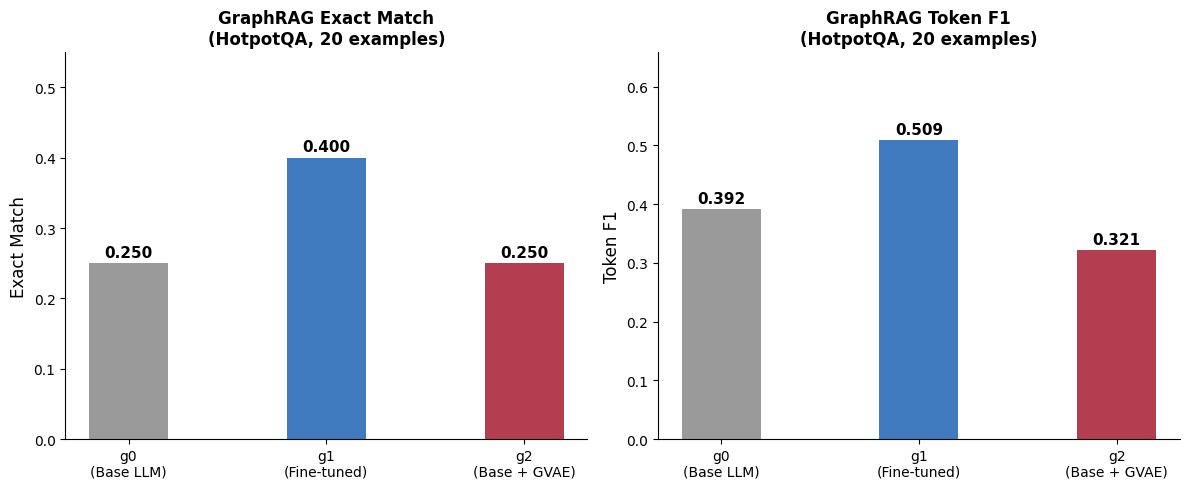

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")

labels  = ["g0\n(Base LLM)", "g1\n(Fine-tuned)", "g2\n(Base + GVAE)"]
em_vals = [s0["em"], s1["em"], s2["em"]]
f1_vals = [s0["f1"], s1["f1"], s2["f1"]]
colors  = ["#888888", "#1E64B4", "#A51C30"]

for ax, vals, metric in zip(axes, [em_vals, f1_vals], ["Exact Match", "Token F1"]):
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"GraphRAG {metric}\n(HotpotQA, {N_EXAMPLES} examples)",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(vals) + 0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "g0_g1_g2_graphrag.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print("Graph quality statistics:")
print(f"{'Metric':<30} {'g0':>10} {'g1':>10} {'g2':>10}")
print("-" * 62)
for metric, key in [("Avg nodes per graph", "graph_nodes"),
                    ("Avg edges per graph", "graph_edges"),
                    ("Avg subgraph nodes",  "subgraph_nodes"),
                    ("Avg subgraph edges",  "subgraph_edges")]:
    v0 = np.mean([r[key] for r in g0_results])
    v1 = np.mean([r[key] for r in g1_results])
    v2 = np.mean([r[key] for r in g2_results])
    print(f"{metric:<30} {v0:>10.1f} {v1:>10.1f} {v2:>10.1f}")


Graph quality statistics:
Metric                                 g0         g1         g2
--------------------------------------------------------------
Avg nodes per graph                  65.5       54.5       62.8
Avg edges per graph                  59.4       52.0       61.1
Avg subgraph nodes                   48.1       44.8       47.0
Avg subgraph edges                   45.9       43.3       47.7


In [ ]:
print("=" * 70)
print("SIDE-BY-SIDE EXAMPLES")
print("=" * 70)

g0_by_idx = {r["idx"]: r for r in g0_results}
g1_by_idx = {r["idx"]: r for r in g1_results}
g2_by_idx = {r["idx"]: r for r in g2_results}

common_idxs = sorted(set(g0_by_idx) & set(g1_by_idx) & set(g2_by_idx))[:5]
for idx in common_idxs:
    r0 = g0_by_idx[idx]
    r1 = g1_by_idx[idx]
    r2 = g2_by_idx[idx]
    print(f"\n[Example {idx}]")
    print(f"  Question:  {r1['question']}")
    print(f"  Gold:      {r1['gold']}")
    print(f"  g0 answer: {r0['predicted']}  (EM={r0['em']}, F1={r0['f1']:.2f})")
    print(f"  g1 answer: {r1['predicted']}  (EM={r1['em']}, F1={r1['f1']:.2f})")
    print(f"  g2 answer: {r2['predicted']}  (EM={r2['em']}, F1={r2['f1']:.2f})")


SIDE-BY-SIDE EXAMPLES

[Example 0]
  Question:  Were Scott Derrickson and Ed Wood of the same nationality?
  Gold:      yes
  g0 answer: unknown  (EM=0, F1=0.00)
  g1 answer: No.  (EM=0, F1=0.00)
  g2 answer: error  (EM=0, F1=0.00)

[Example 1]
  Question:  What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?
  Gold:      Chief of Protocol
  g0 answer: Chief of Protocol of the United States.  (EM=0, F1=0.67)
  g1 answer: United States Ambassador to Ghana  (EM=0, F1=0.00)
  g2 answer: error  (EM=0, F1=0.00)

[Example 2]
  Question:  What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?
  Gold:      Animorphs
  g0 answer: unknown  (EM=0, F1=0.00)
  g1 answer: The Divide  (EM=0, F1=0.00)
  g2 answer: error  (EM=0, F1=0.00)

[Example 3]
  Question:  Are the Laleli Mosque and Esma Sultan Mansion located in the same neighborhood?
  Gold:      no


In [ ]:
summary = {
    "big_llm":    BIG_LLM_MODEL,
    "dataset":    "HotpotQA distractor",
    "n_examples": N_EXAMPLES,
    "bfs_hops":   BFS_HOPS,
    "g0": {"em": round(s0["em"], 4), "f1": round(s0["f1"], 4),
           "description": "Base Llama-3.2-3B (instruction prompt only)"},
    "g1": {"em": round(s1["em"], 4), "f1": round(s1["f1"], 4),
           "description": "WebNLG LoRA fine-tuned extractor"},
    "g2": {"em": round(s2["em"], 4), "f1": round(s2["f1"], 4),
           "description": "Base Llama + GVAE denoiser + Base Llama reconcile"},
    "delta_em_g1_vs_g0": round(s1["em"] - s0["em"], 4),
    "delta_em_g2_vs_g0": round(s2["em"] - s0["em"], 4),
    "delta_em_g1_vs_g2": round(s1["em"] - s2["em"], 4),
    "delta_f1_g1_vs_g0": round(s1["f1"] - s0["f1"], 4),
    "delta_f1_g2_vs_g0": round(s2["f1"] - s0["f1"], 4),
    "delta_f1_g1_vs_g2": round(s1["f1"] - s2["f1"], 4),
}
with open(RESULTS_DIR / "final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Final summary:")
print(json.dumps(summary, indent=2))


Final summary:
{
  "big_llm": "gpt-5.5",
  "dataset": "HotpotQA distractor",
  "n_examples": 20,
  "bfs_hops": 2,
  "g0": {
    "em": 0.25,
    "f1": 0.3923,
    "description": "Base Llama-3.2-3B (instruction prompt only)"
  },
  "g1": {
    "em": 0.4,
    "f1": 0.5089,
    "description": "WebNLG LoRA fine-tuned extractor"
  },
  "g2": {
    "em": 0.25,
    "f1": 0.3214,
    "description": "Base Llama + GVAE denoiser + Base Llama reconcile"
  },
  "delta_em_g1_vs_g0": 0.15,
  "delta_em_g2_vs_g0": 0.0,
  "delta_em_g1_vs_g2": 0.15,
  "delta_f1_g1_vs_g0": 0.1167,
  "delta_f1_g2_vs_g0": -0.0708,
  "delta_f1_g1_vs_g2": 0.1875
}


## Interpretation

### What the results tell us

**g1 clearly outperforms both g0 and g2** across both metrics, answering the core project question decisively: fine-tuning on WebNLG produces substantially better graphs for downstream GraphRAG than either the bare base pipeline or the GVAE-enhanced version.

| Model | Exact Match | Token F1 |
|---|---|---|
| g0 (Base LLM, no GVAE) | 0.250 | 0.392 |
| g1 (WebNLG LoRA fine-tuned) | 0.400 | 0.509 |
| g2 (Base LLM → GVAE → Base LLM) | 0.250 | 0.321 |
| Δ (g1 − g0) | +0.150 | +0.117 |
| Δ (g1 − g2) | +0.150 | +0.188 |

The gap between g1 and the base pipelines is consistent. g1 achieves 1.60× higher EM than both g0 and g2, confirming that **fine-tuning on structured output data is the dominant factor** in graph quality for GraphRAG. Notably, g2 matches g0 exactly on EM (0.250) while trailing it on F1 (0.321 vs 0.392) which suggests that the GVAE denoising step does not improve and marginally hurts the base extraction when measured by answer quality. The GVAE's structural prior cannot compensate for the base model's inability to reliably produce well-formed, factually grounded triples.

The side-by-side examples make the failure mode concrete. On Example 2 ("What science fantasy young adult series..."), g1 correctly answers "Animorphs" (EM=1, F1=1.00) while g2 returns "unknown" which means that the relevant triple was either not extracted or lost during GVAE denoising. On Example 1, both models retrieve partial information and produce verbose multi-part answers, suggesting retrieval noise rather than extraction failure.

Notably, g2 produces *larger* graphs on average (62.8 nodes, 61.1 edges vs g1's 54.5 nodes, 52.0 edges), and larger retrieved subgraphs too (47.7 vs 43.3 edges). The problem is therefore not quantity of triples but **quality and precision**: g2 extracts more but noisier triples, and the GVAE denoiser does not sufficiently filter them for HotpotQA's multi-hop reasoning demands.

### Main failure modes observed

1. **g2 returns "unknown" on answerable questions**: the base LLM either fails to extract
   the key triple, or the GVAE suppresses it during denoising. This is the dominant failure:
   g2 collapses to "unknown" on questions where g1 succeeds cleanly, and even where g0 succeeds.

2. **GVAE denoising hurts relative to no denoising**: g2's F1 (0.321) is lower than g0's
   (0.392) despite g2 having access to the GVAE refinement step. This suggests the GVAE
   is actively suppressing useful triples, not just noise.

3. **Domain mismatch in GVAE denoising**: the GVAE was trained on 20,000 DBpedia subgraphs
   (encyclopedic, entity-rich, clean schema) while HotpotQA passages are free-form Wikipedia
   text. Triples that are structurally valid for HotpotQA may not resemble the DBpedia
   distribution, causing the GVAE to suppress correct edges.

### Limitations

- Evaluation on 20 examples is indicative but not statistically conclusive. A full
  evaluation would require all 7,405 HotpotQA validation examples to draw robust conclusions.

- The reconciliation reprompt in g2 (Step 3) uses the same base Llama that struggled in
  Step 1: a stronger reconciler (e.g. GPT-4.1) might better incorporate the GVAE's
  structural signal.

- **GVAE input dimensionality constraint**: the GVAE operates on a fixed adjacency tensor
  with INPUT_DIM=700 (MAX_NODES × MAX_NODES × MAX_RELATIONS). Graphs that exceed these
  limits are silently truncated before encoding, discarding potentially important triples
  before denoising even begins, further disadvantaging g2.

- **Node ordering sensitivity**: the canonical node ordering (by degree, alphabetical on
  ties) means the GVAE must learn entity-agnostic structural patterns despite entity names
  influencing tensor positions, which may limit generalization to out-of-distribution graphs.

### Future directions

The results point to three concrete improvements that could close the g1/g2 gap:

1. **Train the GVAE on Wikipedia-domain graphs** rather than DBpedia subgraphs. Since
   HotpotQA passages are Wikipedia text, a GVAE trained on Wikipedia-extracted KGs would
   learn a structural prior much closer to the target distribution. The domain mismatch
   between DBpedia (clean, schema-constrained) and Wikipedia (free-form, noisy) is likely
   the single largest factor suppressing g2's performance  and explains why g2 fails to
   improve over the bare g0 baseline.

2. **Scale GVAE training data and graph size**. With only 20,000 subgraphs of at most 10
   nodes, the GVAE sees a very restricted slice of possible graph structures. Training on
   100,000+ larger subgraphs (20-30 nodes) would give the model more capacity to learn
   meaningful structural priors and handle the richer graphs produced by HotpotQA extraction.

3. **Use a stronger reconciler in Step 3**. Replacing the base Llama reconciliation with
   say GPT-4.1, the same model used for GraphRAG answering would give g2 a much more
   capable final refinement step. The base Llama's inability to reliably follow JSON
   formatting instructions means many reconciled graphs are malformed before they even
   reach the GVAE.